# LSTM Model Version Dave 1

## Goal & Setup

- **Task:** given the past week of weather, predict the next 24 hours
- **Target:** start with a **single variable** (e.g. `temperature`) — predicting multiple targets is a later extension (noted in Phase 3)
- **Data:** 4-year subset of hourly weather (~35,000 rows) to keep experiments fast
- **Approach:** direct multi-step forecast — the model outputs all 24 future values at once via a `Dense(24)` head


In [24]:
# Data Import
import sys
# sys.path.append('../notebooks/Jacques')
# from full_cleaning_preprocessing_script import run_full_preprocessing

# General
import pandas as pd
import numpy as np
import os
from typing import List
import matplotlib.pyplot as plt

# Metrics Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep Learning Architecture
from keras import models, Input, layers, optimizers, regularizers
from keras.layers import Normalization
from keras.optimizers.schedules import ExponentialDecay
from keras.callbacks import EarlyStopping
from keras.losses import Huber

## Phase 0 — Inputs (what the model expects)

In [25]:
# df = run_full_preprocessing(
#     data_folder = "/home/jpelletier/Downloads/data",
#     start_date = "2019-01-01",
#     end_date = "2024-12-31",
#     save_path = "/home/jpelletier/Downloads/data/preprocessed_data.csv"
# )

In [26]:
#DAVID: reads the csv direectly from the local folder

df = pd.read_csv('preprocessed_data.csv')
df['datetime_utc12'] = pd.to_datetime(df['datetime_utc12'])
df.set_index('datetime_utc12', inplace=True)

In [27]:
print(df.shape)
print(df.columns.tolist())
df.head()

(52585, 80)
['el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201', 'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201', 'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201', 'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201', 'el_price_dol_MWh_WKM2201', 'Coal', 'Diesel', 'Ele', 'Gas', 'Geo', 'Hydro', 'Solar', 'Wind', 'Wood', 'palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg', 'wellington_wind_kmh', 'wellington_wind_dir_deg', 'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg', 'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg', 'auckland_shortwave_wm2', 'auckland_sunshine_s', 'christchurch_shortwave_wm2', 'christchurch_sunshine_s', 'wellington_shortwave_wm2', 'wellington_sunshine_s', 'hamilton_shortwave_wm2', 'hamilton_sunshine_s', 'tauranga_shortwave_wm2', 'tauranga_sunshine_s', 'dunedin_shortwave_wm2', 'dunedin_sunshine_s', 'auckland_temp_c', 'christchurch_temp_c', 'wel

,el_price_dol_MWh_BEN2201,el_price_dol_MWh_HAY2201,el_price_dol_MWh_INV2201,el_price_dol_MWh_ISL2201,el_price_dol_MWh_KIK2201,el_price_dol_MWh_OTA2201,el_price_dol_MWh_RDF2201,el_price_dol_MWh_SFD2201,el_price_dol_MWh_WKM2201,Coal,...,demand_GWh_UNI,demand_GWh_USI,avg_flow_MW,peak_flow_MW,Direction,outage_Gas_MW,outage_Hyd_MW,outage_Ter_MW,outage_Win_MW,outage_UNKN_MW
datetime_utc12,,,,,,,,,,,,,,,,,,,,,
2019-01-01 00:00:00,169.985,171.76,180.715,181.835,184.255,176.515,166.425,169.515,167.185,0.0,...,0.910,0.528,137.5,148.0,1.0,40.0,84.0,590.0,48.3,14.0
2019-01-01 01:00:00,156.335,157.87,166.360,167.215,169.400,162.070,152.940,155.645,153.635,0.0,...,0.889,0.483,129.5,133.0,1.0,40.0,84.0,590.0,48.3,14.0
2019-01-01 02:00:00,139.650,141.00,148.550,149.095,151.050,144.645,136.500,138.990,137.120,0.0,...,0.853,0.457,126.0,128.0,1.0,40.0,84.0,590.0,48.3,14.0
2019-01-01 03:00:00,128.845,129.98,137.375,137.215,139.015,133.355,125.830,128.130,126.400,0.0,...,0.833,0.446,126.5,132.0,1.0,40.0,84.0,590.0,48.3,14.0
2019-01-01 04:00:00,134.865,136.14,144.585,143.745,145.670,139.955,132.130,134.465,132.725,0.0,...,0.835,0.460,146.0,155.0,1.0,40.0,84.0,590.0,48.3,14.0


## Create Naive Baseline

In [28]:
# Naive baseline: "tomorrow looks like the same hour today" = shift(24).
# Kept as a SEPARATE Series, NOT a column in df, so it never enters the
# feature matrix. We compare it against the model's test predictions later.

TARGET = 'el_price_dol_MWh_OTA2201'

naive_baseline = df[TARGET].shift(24).rename('naive_baseline')


In [29]:
# Evaluate the naive baseline over all rows where it's defined (first 24 are NaN)
mask = naive_baseline.notna()
mae  = mean_absolute_error(df.loc[mask, TARGET], naive_baseline[mask])
rmse = np.sqrt(mean_squared_error(df.loc[mask, TARGET], naive_baseline[mask]))
print(f'Naive (shift-24) MAE  : {mae:.4f}')
print(f'Naive (shift-24) RMSE : {rmse:.4f}')

Naive (shift-24) MAE  : 44.1124
Naive (shift-24) RMSE : 94.2925


## Phase 1 — Lastmile Preprocessing

### Observations

Some columns with 18 and 6 missing values. Will simply impute and fill given extremely low percentage of these values (0.03% and 0.01%, respectivelly.

Check with:
- df.isnull().sum()
- df.isnull().sum() / len(df) * 100

In [30]:
pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)
# pd.reset_option('display.max_rows')

In [31]:
# 1. Ensure chronological order, no gaps
df = df.sort_index()

In [32]:
# 2. Handle missing values + shift weather to simulate forecast availability
#
# WEATHER SHIFT (shift(-24)):
#   When predicting Saturday from a window ending Friday 23:00, we genuinely
#   have Saturday's weather (forecast). shift(-24) pulls each weather value UP
#   by 24 rows so Saturday's weather lands on the Friday row, inside the input
#   window. The LAST 24 rows lose their weather (nothing below to pull) -> NaN,
#   which the bfill below mops up. NOTE: we use ACTUAL future weather here, not
#   a real forecast, so test scores will be slightly optimistic vs deployment.
weather_cols = [
    'palmerston_north_wind_kmh', 'palmerston_north_wind_dir_deg',
    'wellington_wind_kmh', 'wellington_wind_dir_deg',
    'harapaki_hawkesbay_wind_kmh', 'harapaki_hawkesbay_wind_dir_deg',
    'te_uku_waikato_wind_kmh', 'te_uku_waikato_wind_dir_deg',
    'kaiwera_downs_southland_wind_kmh', 'kaiwera_downs_southland_wind_dir_deg',
    'auckland_shortwave_wm2', 'auckland_sunshine_s',
    'christchurch_shortwave_wm2', 'christchurch_sunshine_s',
    'wellington_shortwave_wm2', 'wellington_sunshine_s',
    'hamilton_shortwave_wm2', 'hamilton_sunshine_s',
    'tauranga_shortwave_wm2', 'tauranga_sunshine_s',
    'dunedin_shortwave_wm2', 'dunedin_sunshine_s',
    'auckland_temp_c', 'christchurch_temp_c', 'wellington_temp_c',
    'hamilton_temp_c', 'tauranga_temp_c', 'dunedin_temp_c',
]
df[weather_cols] = df[weather_cols].shift(-24)

# Forward-fill carries the last reading; back-fill covers leading AND the new
# trailing NaNs created by the weather shift.
df = df.ffill().bfill()

In [33]:
# 3. Add cyclical time features — helps the model learn daily & yearly rhythm
#    (Same sin/cos trick as the generation-data cyclic encoding)
hour = df.index.hour
doy  = df.index.dayofyear
df['hour_sin'] = np.sin(2 * np.pi * hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * hour / 24)
df['doy_sin']  = np.sin(2 * np.pi * doy / 365)
df['doy_cos']  = np.cos(2 * np.pi * doy / 365)

In [34]:
# Day-of-week cyclic feature (Mon..Sun as a circle)
dow = df.index.dayofweek          # 0=Mon ... 6=Sun
df['dow_sin'] = np.sin(2 * np.pi * dow / 7)
df['dow_cos'] = np.cos(2 * np.pi * dow / 7)

In [35]:
# 3b. Price-derived rolling features (backward-only -> no leakage)
#     .rolling(24) uses the current row + previous 23 = past 24h only.
TARGET = 'el_price_dol_MWh_OTA2201'   # keep in sync with Phase 2 config

price_cols = [
    'el_price_dol_MWh_BEN2201', 'el_price_dol_MWh_HAY2201',
    'el_price_dol_MWh_INV2201', 'el_price_dol_MWh_ISL2201',
    'el_price_dol_MWh_KIK2201', 'el_price_dol_MWh_OTA2201',
    'el_price_dol_MWh_RDF2201', 'el_price_dol_MWh_SFD2201',
    'el_price_dol_MWh_WKM2201',
]

# Rolling 24h mean of the target node
df['target_roll24'] = df[TARGET].rolling(window=24, min_periods=1).mean()

# Rolling 24h mean of the all-node average (all 9 nodes, incl. target)
df['all_price_mean']        = df[price_cols].mean(axis=1)
df['all_price_roll24']      = df['all_price_mean'].rolling(window=24, min_periods=1).mean()
df = df.drop(columns='all_price_mean')   # keep only the rolled version

In [36]:
# 3c. Cyclic encoding of wind direction (degrees are circular: 359° ≈ 1°)
#     Replace each *_wind_dir_deg with sin/cos so the model sees continuity.
wind_dir_cols = [
    'palmerston_north_wind_dir_deg', 'wellington_wind_dir_deg',
    'harapaki_hawkesbay_wind_dir_deg', 'te_uku_waikato_wind_dir_deg',
    'kaiwera_downs_southland_wind_dir_deg',
]
for col in wind_dir_cols:
    rad = np.deg2rad(df[col])
    base = col.replace('_deg', '')          # e.g. wellington_wind_dir
    df[f'{base}_sin'] = np.sin(rad)
    df[f'{base}_cos'] = np.cos(rad)
df = df.drop(columns=wind_dir_cols)

> **Leakage handling (this model):**
> - The sliding window in Phase 2 ends one full day before the predicted hours, so for every column the freshest value the model sees is from the day *before* the target day. That makes prices, production, and demand honest with no manual lag.
> - **Weather is the one exception:** we `shift(-24)` it (in Phase 1, step 2) so the target day's weather lands inside the input window — simulating having tomorrow's forecast. Caveat: we use *actual* future weather, so scores are mildly optimistic.
> - Rolling price features use backward-only windows, so they add no leakage.

## Phase 2 — Data Preparation (Time Series sequences)

In [37]:
# ─── Configuration (all TUNE-able) ──────────────────────────────────
TARGET           = 'el_price_dol_MWh_OTA2201'   # TUNE: the price variable to predict
INPUT_LENGTH     = 336            # TUNE: 7 days of hourly history as input. CHANGE LATER TO 336 TO LOOK AT 2 WEEKS
OUTPUT_LENGTH    = 24              # fixed: predict 24 hours ahead
HORIZON          = 1               # gap between last input and first prediction
STRIDE           = 12             # TUNE: step between consecutive sequences


# Index of the target column WITHIN the feature array (needed for the baseline)
TARGET_COLUMN_IDX = df.columns.get_loc(TARGET)

# Expanding-window CV settings
INIT_TRAIN = 24 * 365 * 3   # 3 years initial training
STEP       = 24 * 60        # expand by ~2 months each fold
TEST_LEN   = 24 * 60        # test on the next ~2 months

In [38]:
# ─── Step 1: Expanding-window walk-forward folds ────────────────────
# Training set always starts at row 0 and GROWS each fold; test slides forward.
# Each fold returns (train_slice, test_slice). The test slice is prepended with
# INPUT_LENGTH rows of lookback so its first window can form without peeking
# into train (same horizon-gap logic as the fixed-fold version).
def get_expanding_folds(df, init_train, step, test_len, input_length, horizon):
    folds = []
    train_end = init_train
    while train_end + test_len <= len(df):
        train = df.iloc[:train_end]
        test_start = train_end - input_length + horizon   # lookback + gap
        test  = df.iloc[test_start : train_end + test_len]
        folds.append((train, test))
        train_end += step
    return folds

In [39]:
# ─── Step 2: Chronological train/test split per fold (with horizon gap) ──
def train_test_split(fold, train_test_ratio, input_length, horizon):
    train_end  = round(train_test_ratio * len(fold))
    test_start = train_end - input_length + horizon   # leaves lookback + gap
    return fold.iloc[:train_end], fold.iloc[test_start:]

In [40]:
# ─── Step 3: Extract (Xi, yi) sequence pairs (vectorised) ────────────
from numpy.lib.stride_tricks import sliding_window_view

def get_X_y(fold, horizon, input_length, output_length, stride, shuffle=True):
    arr = fold.values.astype(np.float32)
    tgt = fold[TARGET].values.astype(np.float32)
    n = len(fold)
    last_start = n - input_length - horizon - output_length + 2

    starts = np.arange(0, last_start, stride)
    X_all = sliding_window_view(arr, input_length, axis=0)      # (n-IL+1, F, IL)
    X = X_all[starts].transpose(0, 2, 1)                        # (samples, IL, F)

    y_starts = starts + input_length + horizon - 1
    y_all = sliding_window_view(tgt, output_length)            # (n-OL+1, OL)
    y = y_all[y_starts]

    if shuffle:
        idx = np.random.permutation(len(X))
        X, y = X[idx], y[idx]
    return X, y

In [41]:
folds = get_expanding_folds(df, INIT_TRAIN, STEP, TEST_LEN, INPUT_LENGTH, HORIZON)

# Sanity-check shapes on the FIRST fold
fold_train, fold_test = folds[0]
X_train, y_train = get_X_y(fold_train, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE)
X_test,  y_test  = get_X_y(fold_test,  HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)

print(f"Number of folds: {len(folds)}")
print(f"N_FEATURES: {X_train.shape[2]}")   # expect ~93 after all Phase 1 features
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}")


Number of folds: 18
N_FEATURES: 93
X_train: (2161, 336, 93)
y_train: (2161, 24)
X_test:  (118, 336, 93)


## Phase 3 — Architecture

In [ ]:
def init_model(X_train):
    # Normalization baked into the model, fitted on TRAIN data only (no leakage)
    normalizer = Normalization()
    normalizer.adapt(X_train)

    model = models.Sequential()
    model.add(Input(shape=X_train[0].shape))     # (INPUT_LENGTH, N_FEATURES)
    model.add(normalizer)

    # Stacked recurrent layers (depth helps sequence modelling)
    model.add(layers.LSTM(units=64,
                          activation='tanh',
                          return_sequences=True,   # pass full sequence to next LSTM
                          dropout=0.2))
    model.add(layers.LSTM(units=32,
                          activation='tanh',
                          return_sequences=False,  # last layer collapses to vector
                          dropout=0.2))



    # Dense hidden layer
    model.add(layers.Dense(32, activation='relu'))
    model.add(layers.Dropout(0.2))

    # model.add(layers.Dense(16, activation='relu'))
    # model.add(layers.Dropout(0.2))

    # Output — one neuron per future timestep (24)
    model.add(layers.Dense(OUTPUT_LENGTH, activation='linear'))

    # Exponential decay learning rate
    lr_schedule = ExponentialDecay(initial_learning_rate=0.01,
                                   decay_steps=1000,
                                   decay_rate=0.5)
    model.compile(loss=Huber(),                    # robust to price spikes
                  optimizer=optimizers.Adam(learning_rate=lr_schedule),
                  metrics=['mae', 'root_mean_squared_error'])
    return model

In [43]:
model = init_model(X_train)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_2 (Normalization) │ (None, 336, 93)        │           187 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 336, 64)        │        40,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 24)             │           792 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,899 (214.45 KB)

 Trainable params: 54,712 (213.72 KB)

 Non-trainable params: 187 (752.00 B)

## Phase 4 — Fit

In [44]:
def fit_model(model, X_train, y_train, verbose=1):
    es = EarlyStopping(monitor='val_loss',
                       patience=8,            # let it converge
                       mode='min',
                       restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split = 0.3,
        shuffle          = False,   # MANDATORY for time series
        batch_size       = 32,
        epochs           = 100,     # early stopping decides the real number
        callbacks        = [es],
        verbose          = verbose,
    )
    return model, history

In [45]:
# ─── Train across all expanding-window folds ────────────────────────
fold_results = []   # collect per-fold scores for next session's evaluation

for i, (fold_train, fold_test) in enumerate(folds):
    print(f"\n===== Fold {i+1}/{len(folds)} =====")

    X_tr, y_tr = get_X_y(fold_train, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE)
    X_te, y_te = get_X_y(fold_test,  HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)

    model = init_model(X_tr)
    model, history = fit_model(model, X_tr, y_tr, verbose=0)

    mae, rmse = model.evaluate(X_te, y_te, verbose=0)[1:3]
    print(f"Fold {i+1}  test MAE: {mae:.3f}  RMSE: {rmse:.3f}")

    fold_results.append({
        'fold': i,
        'train_end': fold_train.index[-1],
        'test_start': fold_test.index[INPUT_LENGTH],
        'test_end': fold_test.index[-1],
        'mae': mae,
        'rmse': rmse,
        'model': model,
        'history': history,
    })

maes  = [r['mae']  for r in fold_results]
rmses = [r['rmse'] for r in fold_results]
print(f"\n=== CV summary over {len(folds)} folds ===")
print(f"MAE : {np.mean(maes):.3f} ± {np.std(maes):.3f}")
print(f"RMSE: {np.mean(rmses):.3f} ± {np.std(rmses):.3f}")


===== Fold 1/18 =====
Fold 1  test MAE: 62.904  RMSE: 88.525

===== Fold 2/18 =====
Fold 2  test MAE: 32.842  RMSE: 53.145

===== Fold 3/18 =====
Fold 3  test MAE: 41.917  RMSE: 86.354

===== Fold 4/18 =====
Fold 4  test MAE: 51.057  RMSE: 66.364

===== Fold 5/18 =====
Fold 5  test MAE: 35.480  RMSE: 86.190

===== Fold 6/18 =====
Fold 6  test MAE: 33.344  RMSE: 57.477

===== Fold 7/18 =====
Fold 7  test MAE: 38.883  RMSE: 90.002

===== Fold 8/18 =====
Fold 8  test MAE: 36.013  RMSE: 49.697

===== Fold 9/18 =====
Fold 9  test MAE: 55.215  RMSE: 193.492

===== Fold 10/18 =====
Fold 10  test MAE: 27.387  RMSE: 40.948

===== Fold 11/18 =====
Fold 11  test MAE: 29.693  RMSE: 40.628

===== Fold 12/18 =====
Fold 12  test MAE: 27.500  RMSE: 41.985

===== Fold 13/18 =====
Fold 13  test MAE: 85.224  RMSE: 110.330

===== Fold 14/18 =====
Fold 14  test MAE: 47.976  RMSE: 68.030

===== Fold 15/18 =====
Fold 15  test MAE: 54.436  RMSE: 188.096

===== Fold 16/18 =====
Fold 16  test MAE: 138.377  RMS

In [52]:
import pickle, os

os.makedirs('fold_models', exist_ok=True)
to_save = []
for r in fold_results:
    r['model'].save(f"fold_models_huber_2weeks/fold_{r['fold']:02d}.keras")
    to_save.append({k: v for k, v in r.items() if k != 'model'})

with open('fold_results_2week_huber.pkl', 'wb') as f:
    pickle.dump(to_save, f)

print(f"Saved {len(to_save)} folds + 18 model files in fold_models/")

Saved 18 folds + 18 model files in fold_models/


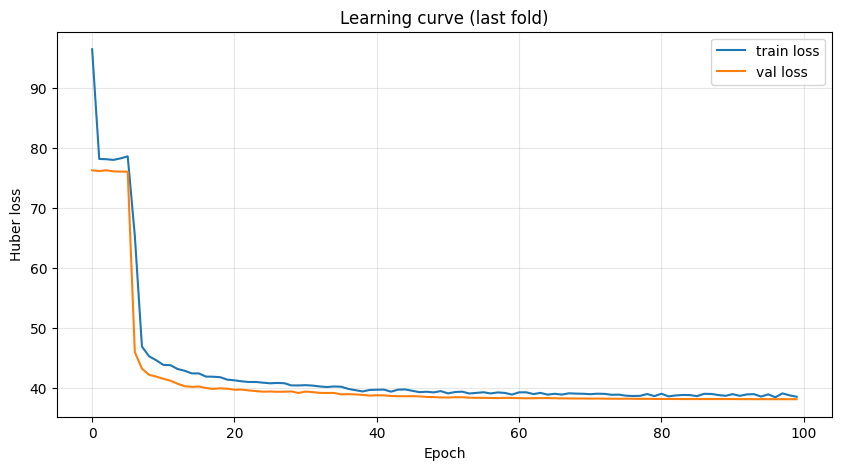

In [46]:
pythonhistory = fold_results[-1]['history']
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'],     label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch'); plt.ylabel('Huber loss'); plt.legend()
plt.title('Learning curve (last fold)'); plt.grid(alpha=0.3)
plt.show()

## Phase 5 — Evaluate & Cross-Validate

Cell A: Compute Naiveseline per fold

In [86]:
from sklearn.metrics import r2_score
import numpy as np

per_fold = []
for i, (_, fold_test) in enumerate(folds):
    X_te, y_te = get_X_y(fold_test, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)
    model = fold_results[i].get('model')
    if model is None:
        import keras
        model = keras.models.load_model(f"fold_models/fold_{i:02d}.keras")
    y_pred  = model.predict(X_te, verbose=0).flatten()
    y_true  = y_te.flatten()
    y_naive = all_naive[i].flatten()

    mae   = np.mean(np.abs(y_true - y_pred))
    rmse  = np.sqrt(np.mean((y_true - y_pred)**2))
    mase  = mae / np.mean(np.abs(y_true - y_naive))
    r2    = r2_score(y_true, y_pred)
    per_fold.append((mae, rmse, mase, r2))

per_fold = np.array(per_fold)
print(f"MAE  : {per_fold[:,0].mean():.3f} ± {per_fold[:,0].std():.3f}")
print(f"RMSE : {per_fold[:,1].mean():.3f} ± {per_fold[:,1].std():.3f}")
print(f"MASE : {per_fold[:,2].mean():.3f} ± {per_fold[:,2].std():.3f}   (<1 beats naive)")
print(f"R²   : {per_fold[:,3].mean():.3f} ± {per_fold[:,3].std():.3f}")

MAE  : 49.101 ± 26.230
RMSE : 94.284 ± 52.837
MASE : 0.996 ± 0.249   (<1 beats naive)
R²   : 0.185 ± 0.217


In [76]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

naive_results = []
all_naive = []
for i, (_, fold_test) in enumerate(folds):
    X_te, y_te = get_X_y(fold_test, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)

    n_samples = len(y_te)
    naive_pred = np.zeros_like(y_te)
    for s in range(n_samples):
        start = s * STRIDE
        pred_pos = start + INPUT_LENGTH + HORIZON - 1   # row position of first predicted hour
        pred_timestamps = fold_test.index[pred_pos : pred_pos + OUTPUT_LENGTH]
        naive_pred[s] = naive_baseline.loc[pred_timestamps].values

    all_naive.append(naive_pred)
    mae  = mean_absolute_error(y_te.flatten(), naive_pred.flatten())
    rmse = np.sqrt(mean_squared_error(y_te.flatten(), naive_pred.flatten()))
    naive_results.append({'fold': i, 'mae': mae, 'rmse': rmse})
    print(f"Fold {i+1:2d}  naive MAE: {mae:.2f}  RMSE: {rmse:.2f}")

Fold  1  naive MAE: 62.05  RMSE: 91.11
Fold  2  naive MAE: 31.78  RMSE: 54.71
Fold  3  naive MAE: 46.91  RMSE: 112.60
Fold  4  naive MAE: 49.97  RMSE: 82.26
Fold  5  naive MAE: 41.10  RMSE: 104.30
Fold  6  naive MAE: 29.48  RMSE: 67.13
Fold  7  naive MAE: 44.46  RMSE: 119.02
Fold  8  naive MAE: 40.89  RMSE: 55.67
Fold  9  naive MAE: 63.67  RMSE: 216.02
Fold 10  naive MAE: 33.23  RMSE: 51.39
Fold 11  naive MAE: 32.26  RMSE: 46.76
Fold 12  naive MAE: 34.15  RMSE: 55.13
Fold 13  naive MAE: 57.11  RMSE: 83.85
Fold 14  naive MAE: 49.47  RMSE: 79.06
Fold 15  naive MAE: 70.77  RMSE: 238.22
Fold 16  naive MAE: 77.63  RMSE: 124.68
Fold 17  naive MAE: 58.83  RMSE: 115.60
Fold 18  naive MAE: 34.80  RMSE: 167.33


### compare naive to model

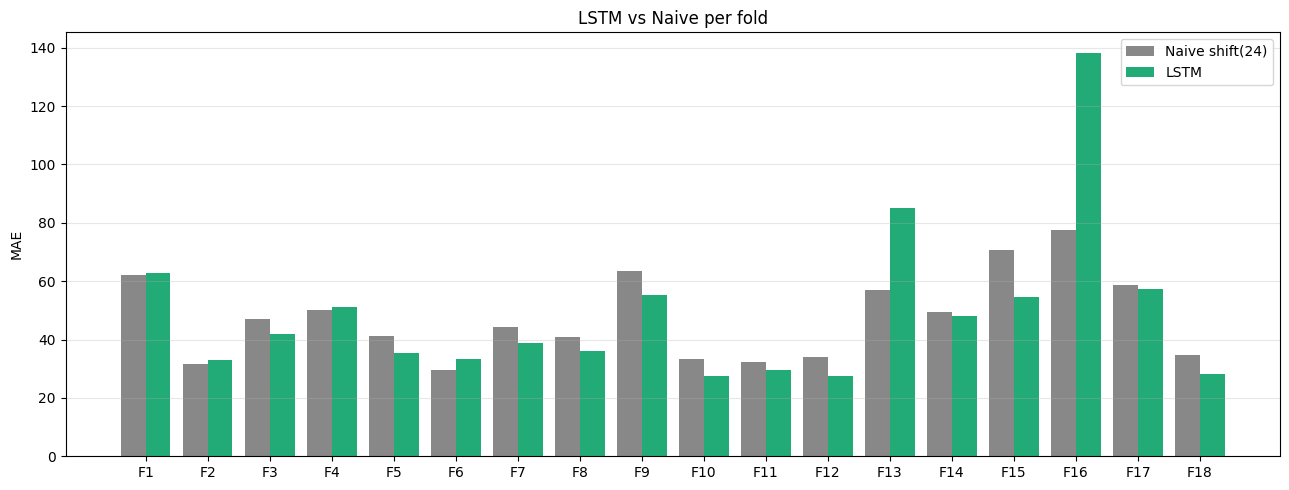

LSTM beats naive in 12/18 folds


In [77]:
import matplotlib.pyplot as plt

lstm_mae  = [r['mae']  for r in fold_results]
naive_mae = [r['mae']  for r in naive_results]
x = np.arange(len(folds))

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - 0.2, naive_mae, width=0.4, label='Naive shift(24)', color='#888')
ax.bar(x + 0.2, lstm_mae,  width=0.4, label='LSTM',            color='#2a7')
ax.set_xticks(x); ax.set_xticklabels([f'F{i+1}' for i in x])
ax.set_ylabel('MAE'); ax.set_title('LSTM vs Naive per fold')
ax.legend(); ax.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

wins = sum(l < n for l, n in zip(lstm_mae, naive_mae))
print(f"LSTM beats naive in {wins}/{len(folds)} folds")

### compare one good and one bad fold

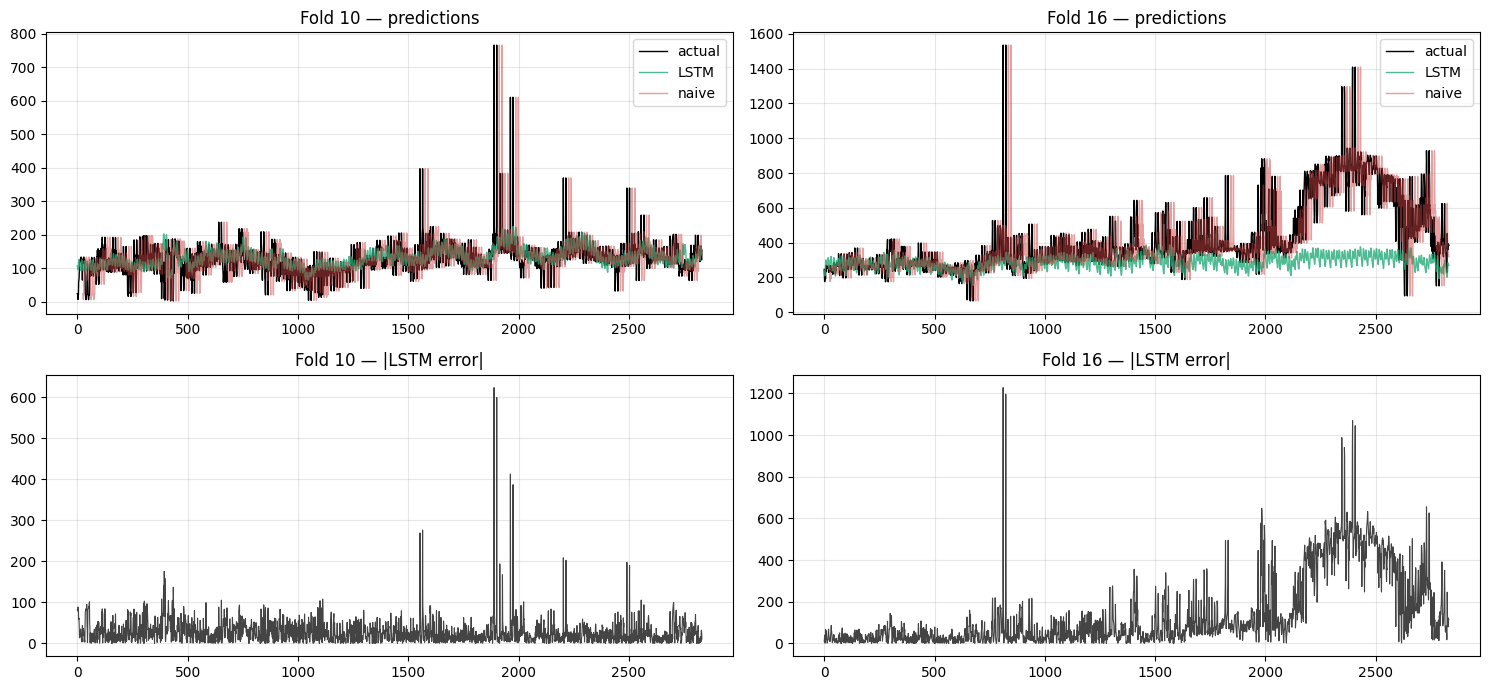

In [83]:
def plot_fold(idx, ax_overlay, ax_err):
    _, fold_test = folds[idx]
    X_te, y_te = get_X_y(fold_test, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)
    model = fold_results[idx].get('model')
    if model is None:
        import keras
        model = keras.models.load_model(f"fold_models/fold_{idx:02d}.keras")
    y_pred = model.predict(X_te, verbose=0)

    actual_t = y_te.flatten()
    lstm_t   = y_pred.flatten()

    naive = np.roll(y_te, 1, axis=0).astype(float)
    naive[0] = np.nan
    naive_t = naive.flatten()

    err_t = np.abs(actual_t - lstm_t)

    ax_overlay.plot(actual_t, label='actual', color='black', linewidth=1)
    ax_overlay.plot(lstm_t,   label='LSTM',   color='#2a7',  linewidth=1, alpha=0.8)
    ax_overlay.plot(naive_t,  label='naive',  color='#c44',  linewidth=1, alpha=0.5)
    ax_overlay.set_title(f'Fold {idx+1} — predictions'); ax_overlay.legend(); ax_overlay.grid(alpha=0.3)

    ax_err.plot(err_t, color='#444', linewidth=0.8)
    ax_err.set_title(f'Fold {idx+1} — |LSTM error|'); ax_err.grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(15, 7))
plot_fold(good_fold, axes[0,0], axes[1,0])
plot_fold(bad_fold,  axes[0,1], axes[1,1])
plt.tight_layout(); plt.show()

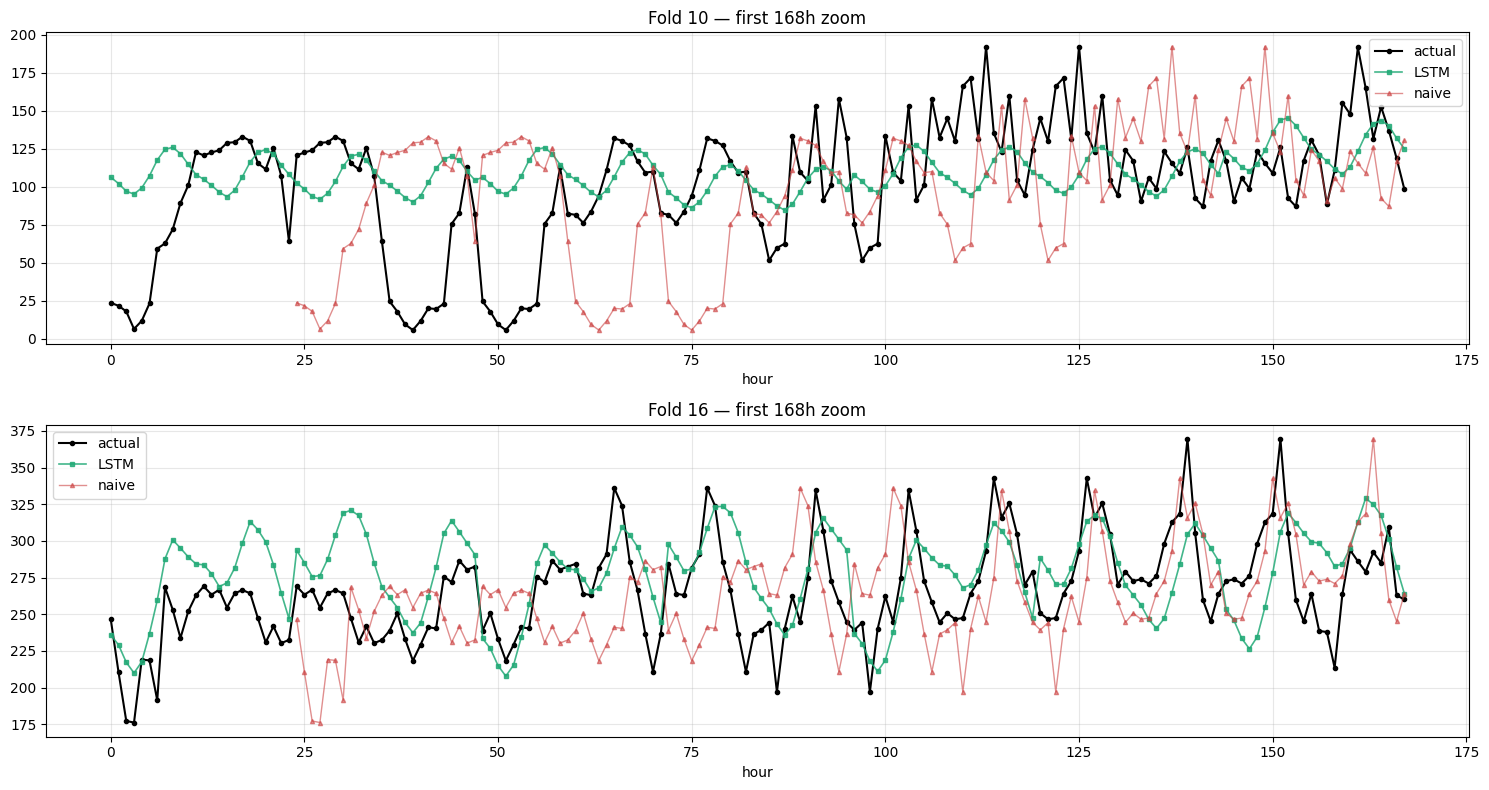

In [81]:
def plot_fold_zoom(idx, ax, start=0):
    _, fold_test = folds[idx]
    X_te, y_te = get_X_y(fold_test, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)
    model = fold_results[idx].get('model')
    if model is None:
        import keras
        model = keras.models.load_model(f"fold_models/fold_{idx:02d}.keras")
    y_pred = model.predict(X_te, verbose=0)

    actual_t = y_te.flatten()
    lstm_t   = y_pred.flatten()

    naive = np.roll(y_te, 1, axis=0).astype(float)
    naive[0] = np.nan
    naive_t = naive.flatten()

    actual_t = actual_t[start:start+ZOOM_HOURS]
    lstm_t   = lstm_t[start:start+ZOOM_HOURS]
    naive_t  = naive_t[start:start+ZOOM_HOURS]

    ax.plot(actual_t, label='actual', color='black', linewidth=1.5, marker='o', markersize=3)
    ax.plot(lstm_t,   label='LSTM',   color='#2a7',  linewidth=1.2, marker='s', markersize=3, alpha=0.85)
    ax.plot(naive_t,  label='naive',  color='#c44',  linewidth=1.0, marker='^', markersize=3, alpha=0.6)
    ax.set_title(f'Fold {idx+1} — first {ZOOM_HOURS}h zoom')
    ax.set_xlabel('hour'); ax.legend(); ax.grid(alpha=0.3)

ZOOM_HOURS = 168

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
plot_fold_zoom(good_fold, axes[0])
plot_fold_zoom(bad_fold,  axes[1])
plt.tight_layout(); plt.show()

### Mean error by hour-of-day (across all folds)

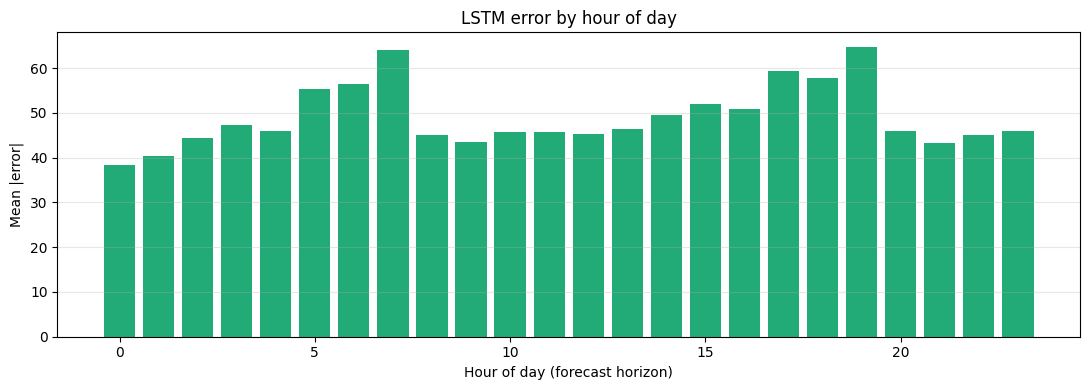

In [56]:
all_actual, all_pred, all_hour = [], [], []
for i, (_, fold_test) in enumerate(folds):
    X_te, y_te = get_X_y(fold_test, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)
    model = fold_results[i].get('model')
    if model is None:
        import keras
        model = keras.models.load_model(f"fold_models/fold_{i:02d}.keras")
    y_pred = model.predict(X_te, verbose=0)
    # Hour-of-day for each predicted point: 0..23 repeating per sample
    hours = np.tile(np.arange(OUTPUT_LENGTH), len(y_te))
    all_actual.append(y_te.flatten()); all_pred.append(y_pred.flatten()); all_hour.append(hours)

actual = np.concatenate(all_actual); pred = np.concatenate(all_pred); hour = np.concatenate(all_hour)
err = np.abs(actual - pred)
mae_by_hour = [err[hour == h].mean() for h in range(24)]

plt.figure(figsize=(11, 4))
plt.bar(range(24), mae_by_hour, color='#2a7')
plt.xlabel('Hour of day (forecast horizon)'); plt.ylabel('Mean |error|')
plt.title('LSTM error by hour of day'); plt.grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

### Residual histogram + scatter pred-vs-actual

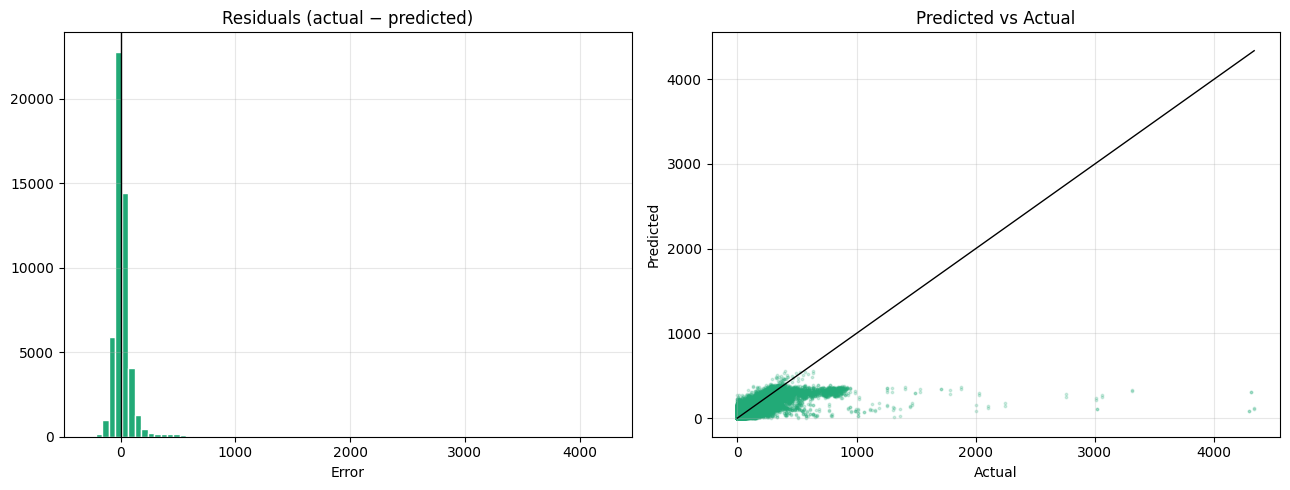

In [57]:
residuals = actual - pred  # reuse arrays from cell D

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(residuals, bins=80, color='#2a7', edgecolor='white')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Residuals (actual − predicted)')
axes[0].set_xlabel('Error'); axes[0].grid(alpha=0.3)

axes[1].scatter(actual, pred, s=3, alpha=0.2, color='#2a7')
lo, hi = actual.min(), actual.max()
axes[1].plot([lo, hi], [lo, hi], color='black', linewidth=1)
axes[1].set_title('Predicted vs Actual'); axes[1].set_xlabel('Actual'); axes[1].set_ylabel('Predicted')
axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

Baseline MAE on fold 10: 27.387
  done 1/93
  done 11/93
  done 21/93
  done 31/93
  done 41/93
  done 51/93
  done 61/93
  done 71/93
  done 81/93
  done 91/93


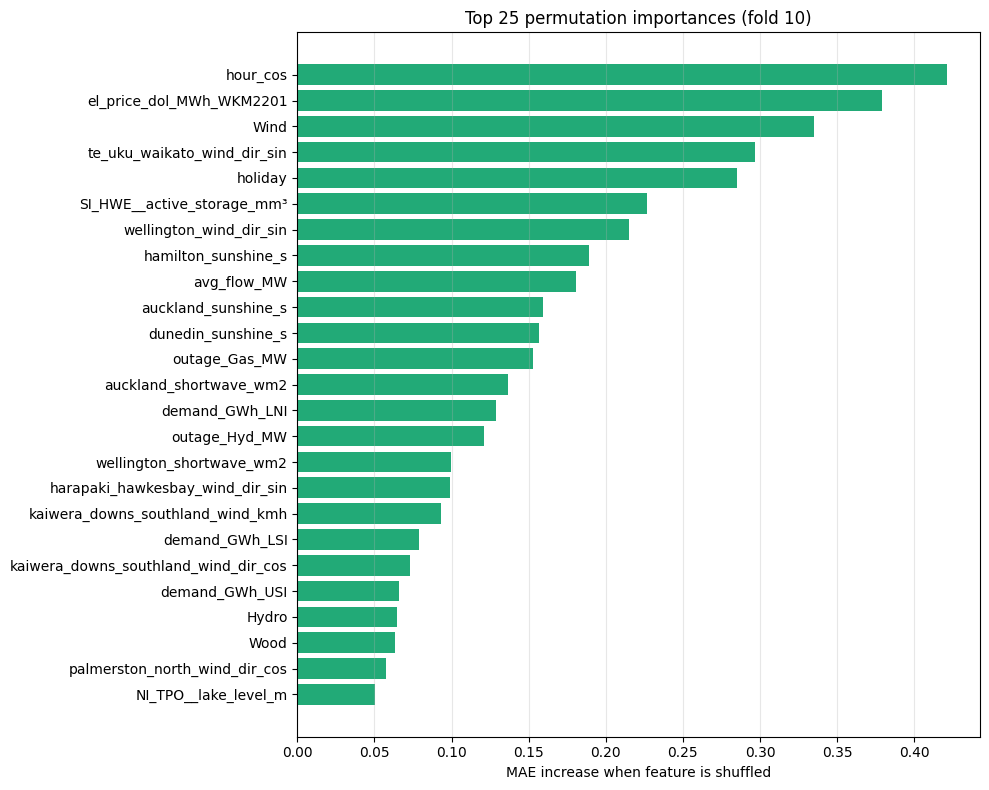

In [85]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

fold_idx = good_fold   # use the strongest fold for cleanest signal
_, fold_test = folds[fold_idx]
X_te, y_te = get_X_y(fold_test, HORIZON, INPUT_LENGTH, OUTPUT_LENGTH, STRIDE, shuffle=False)

model = fold_results[fold_idx].get('model')
if model is None:
    import keras
    model = keras.models.load_model(f"fold_models/fold_{fold_idx:02d}.keras")

# Baseline error
base_pred = model.predict(X_te, verbose=0)
base_mae  = mean_absolute_error(y_te.flatten(), base_pred.flatten())
print(f"Baseline MAE on fold {fold_idx+1}: {base_mae:.3f}")

feature_names = df.columns.tolist()
n_features = X_te.shape[2]
importances = np.zeros(n_features)

rng = np.random.default_rng(15)
for f in range(n_features):
    X_perm = X_te.copy()
    # Shuffle this feature across ALL samples and timesteps
    flat = X_perm[:, :, f].flatten()
    rng.shuffle(flat)
    X_perm[:, :, f] = flat.reshape(X_perm.shape[:2])

    perm_pred = model.predict(X_perm, verbose=0)
    perm_mae  = mean_absolute_error(y_te.flatten(), perm_pred.flatten())
    importances[f] = perm_mae - base_mae
    if f % 10 == 0:
        print(f"  done {f+1}/{n_features}")

# Plot top 25
order = np.argsort(importances)[::-1]
top = 25
plt.figure(figsize=(10, 8))
plt.barh(range(top), importances[order][:top][::-1], color='#2a7')
plt.yticks(range(top), [feature_names[i] for i in order[:top]][::-1])
plt.xlabel('MAE increase when feature is shuffled')
plt.title(f'Top {top} permutation importances (fold {fold_idx+1})')
plt.grid(alpha=0.3, axis='x'); plt.tight_layout(); plt.show()

## Phase 6 — Predict the Next 24 Hours

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 487ms/step
2024-12-31 01:00:00     6.553520
2024-12-31 02:00:00     4.277941
2024-12-31 03:00:00     2.641233
2024-12-31 04:00:00     1.982849
2024-12-31 05:00:00     3.126637
2024-12-31 06:00:00     7.073114
2024-12-31 07:00:00    12.042431
2024-12-31 08:00:00    17.186550
2024-12-31 09:00:00    20.115875
2024-12-31 10:00:00    18.529957
2024-12-31 11:00:00    15.988754
2024-12-31 12:00:00    15.099103
2024-12-31 13:00:00    13.776010
2024-12-31 14:00:00    11.188636
2024-12-31 15:00:00     9.128002
2024-12-31 16:00:00     9.855256
2024-12-31 17:00:00    11.798081
2024-12-31 18:00:00    15.694424
2024-12-31 19:00:00    18.874218
2024-12-31 20:00:00    19.662487
2024-12-31 21:00:00    19.835255
2024-12-31 22:00:00    17.901258
2024-12-31 23:00:00    13.522265
2025-01-01 00:00:00    10.955276
Freq: h, Name: el_price_dol_MWh_OTA2201_forecast, dtype: float32


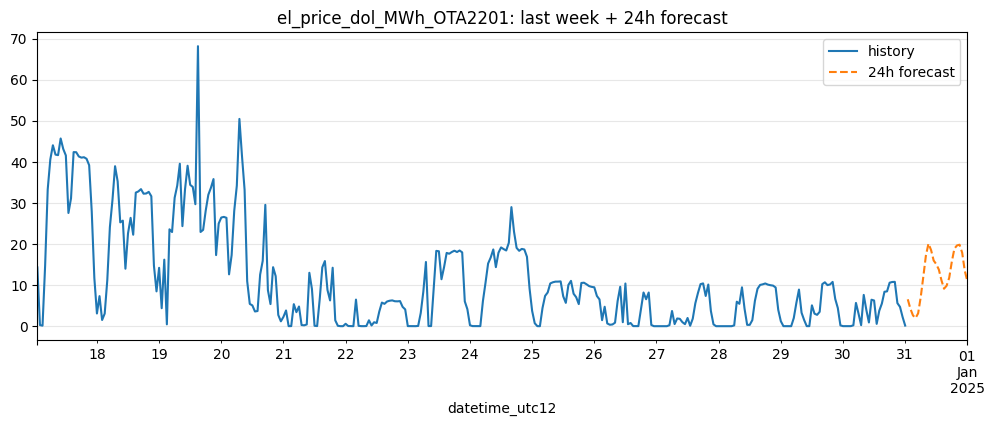

In [48]:
# Build a single input window from the most recent data
latest_window = df.iloc[-INPUT_LENGTH:].values            # (INPUT_LENGTH, N_FEATURES)
latest_window = latest_window[np.newaxis, ...]            # (1, INPUT_LENGTH, N_FEATURES)

# Predict the next 24 hours
forecast_24h = model.predict(latest_window)[0]            # shape (24,)

# Attach future timestamps for readability
last_ts = df.index[-1]
future_index = pd.date_range(last_ts + pd.Timedelta(hours=1), periods=OUTPUT_LENGTH, freq='h')
forecast_series = pd.Series(forecast_24h, index=future_index, name=f'{TARGET}_forecast')

print(forecast_series)

# Quick visual
plt.figure(figsize=(12, 4))
df[TARGET].iloc[-INPUT_LENGTH:].plot(label='history')
forecast_series.plot(label='24h forecast', linestyle='--')
plt.legend(); plt.title(f'{TARGET}: last week + 24h forecast'); plt.grid(alpha=0.3)
plt.show()